##  Objective

In this notebook, we perform a full churn analysis pipeline on the 
Telco Customer Churn dataset, covering:

- **Exploratory Data Analysis (EDA)** to uncover patterns and risk factors
- **Feature Selection** using Mutual Information
- **Predictive Modeling** using XGBoost Classifier wrapped in a Scikit-learn Pipeline
- **Model Explainability** using SHAP values

The goal is to identify customers at high risk of churning and understand 
the key drivers behind their decision to leave.

## IMPORTS 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report , confusion_matrix
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
import shap

## Load Data

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [6]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Data Preprocessing

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [9]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.drop("customerID", axis=1, inplace=True)

## Univariant Analysis

In [13]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='tenure'>

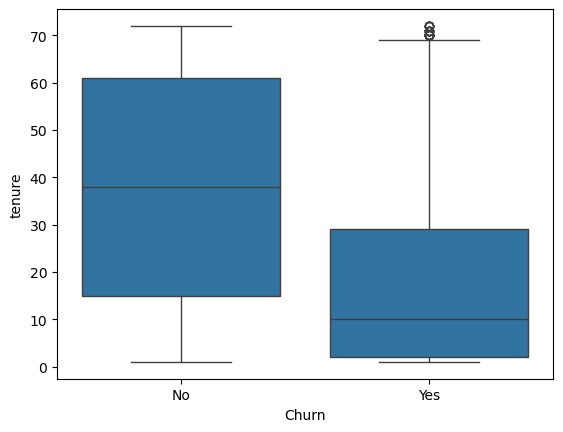

In [14]:
sns.boxplot(x="Churn" , y="tenure" , data =df )

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

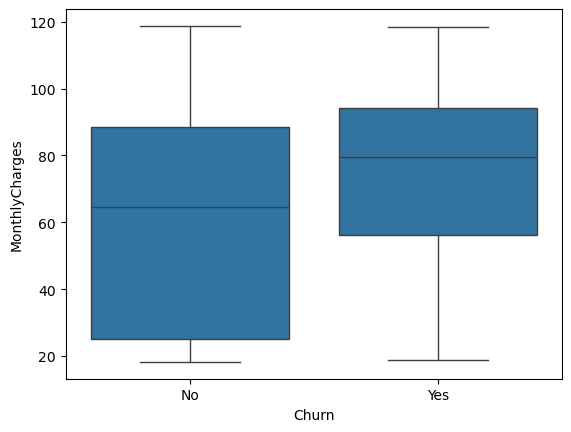

In [15]:
sns.boxplot(x="Churn" , y="MonthlyCharges" , data =df )

<Axes: xlabel='Contract', ylabel='count'>

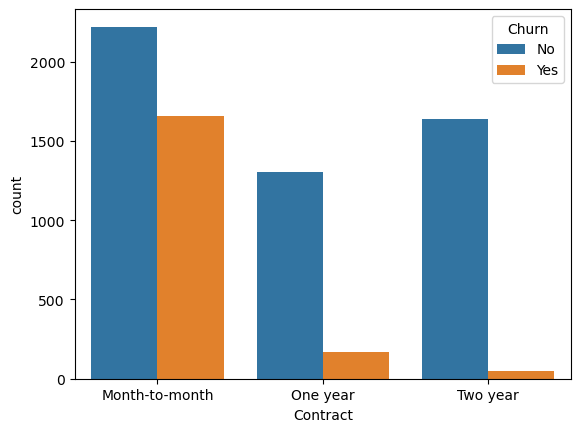

In [16]:
sns.countplot(x='Contract' , hue='Churn' ,data=df)

<Axes: xlabel='InternetService', ylabel='count'>

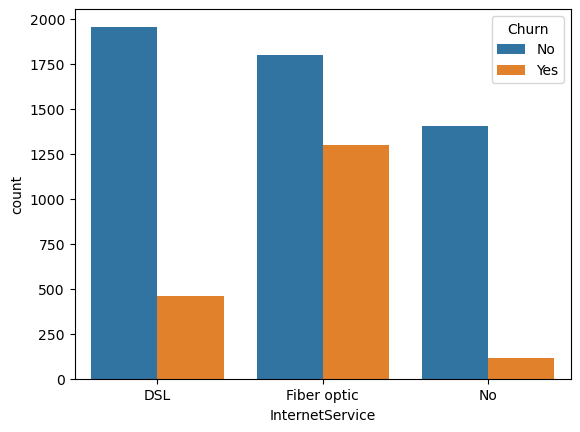

In [17]:
sns.countplot(x='InternetService' , hue='Churn' ,data=df)

<Axes: xlabel='PaperlessBilling', ylabel='count'>

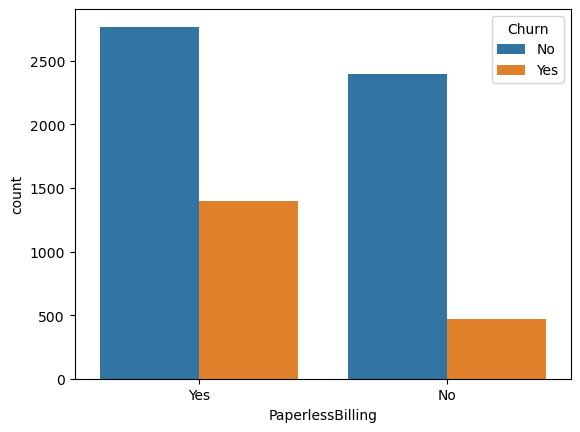

In [18]:
sns.countplot(x='PaperlessBilling' , hue='Churn' ,data=df)

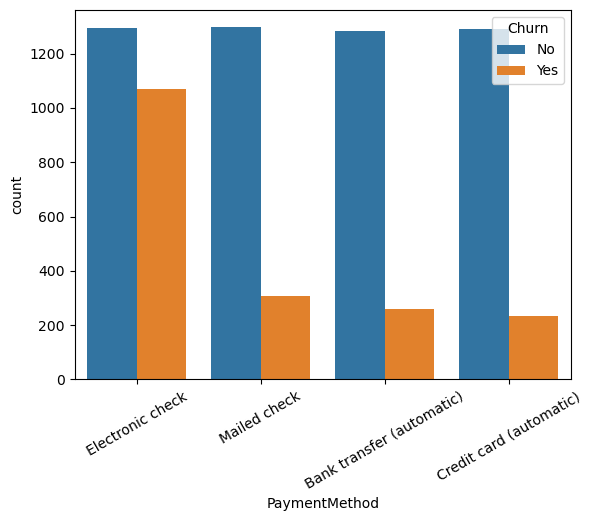

In [19]:
sns.countplot(x='PaymentMethod' , hue='Churn' ,data=df)
plt.tick_params(axis='x' , rotation=30)

<Axes: xlabel='Dependents', ylabel='count'>

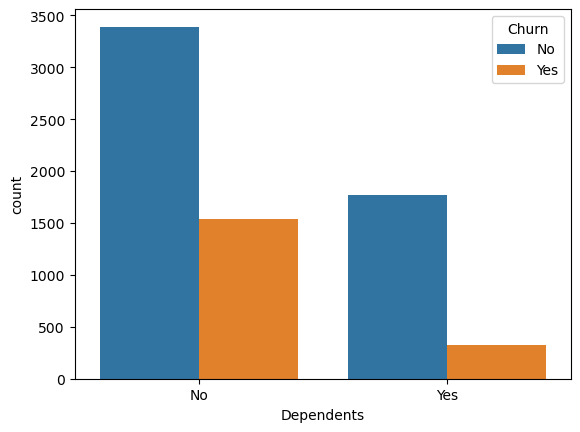

In [20]:
sns.countplot(x='Dependents' , hue='Churn' ,data=df)

In [21]:
higher_risk= df[(df['Contract']=='Month-to-month') & 
(df['InternetService']=='Fiber optic') 
& (df['PaperlessBilling']=='Yes') ]

print(f"Number of high-risk customer = {len(higher_risk)}")
print(f'Percentage = { len(higher_risk)/len(df)*100:2f} % ')

Number of high-risk customer = 1689
Percentage = 24.018771 % 


## Encoding

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

In [23]:
X_train , X_test , y_train , y_test=train_test_split(
    X , y , test_size=0.2 ,random_state=42 , stratify=y
)

In [24]:
cat_cols=X.select_dtypes(include='object').columns

num_cols=X.select_dtypes(exclude='object').columns

preprocessor= ColumnTransformer(
    transformers=[
        ("cat" ,OneHotEncoder(drop='first' , handle_unknown='ignore'),cat_cols),
        ("num" , "passthrough" , num_cols)
    ]
)
    

In [25]:
X_train_encoded = preprocessor.fit_transform(X_train)

In [26]:
feature_names = preprocessor.get_feature_names_out()

encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=feature_names
)

encoded_df.head()

,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_No internet service,cat__OnlineSecurity_Yes,...,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges
0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,65.0,94.55,6078.75
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26.0,35.75,1022.50
2,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,68.0,90.20,6297.65
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,84.30,235.05
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,40.65,2070.75


## Mutual Information

In [27]:
mi = mutual_info_classif(X_train_encoded, y_train, random_state=42)

mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI Score': mi
}).sort_values("MI Score", ascending=False).reset_index(drop=True)

mi_df

,Feature,MI Score
0,num__tenure,0.072538
1,cat__Contract_Two year,0.056934
2,cat__PaymentMethod_Electronic check,0.052457
3,cat__InternetService_Fiber optic,0.051256
4,num__MonthlyCharges,0.049949
5,num__TotalCharges,0.044136
6,cat__StreamingTV_No internet service,0.038557
7,cat__OnlineBackup_No internet service,0.036500
8,cat__DeviceProtection_No internet service,0.032128
9,cat__InternetService_No,0.031974


## Model (XGBoost)

In [28]:
model=XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5 ,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight= len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

In [29]:
clf=Pipeline(steps=[
   ('preprocesor', preprocessor),
   ('model',model)
])

In [30]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMetho...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Evaluation

In [31]:
y_pred=clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.52      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [32]:
from sklearn.metrics import roc_auc_score

y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc:.4f}")

ROC AUC Score: 0.8197


## SHAP explaination

In [33]:
X_test_encoded = preprocessor.transform(X_test)

explainer = shap.Explainer(model)
shap_values = explainer(X_test_encoded)

shap_values.feature_names = feature_names

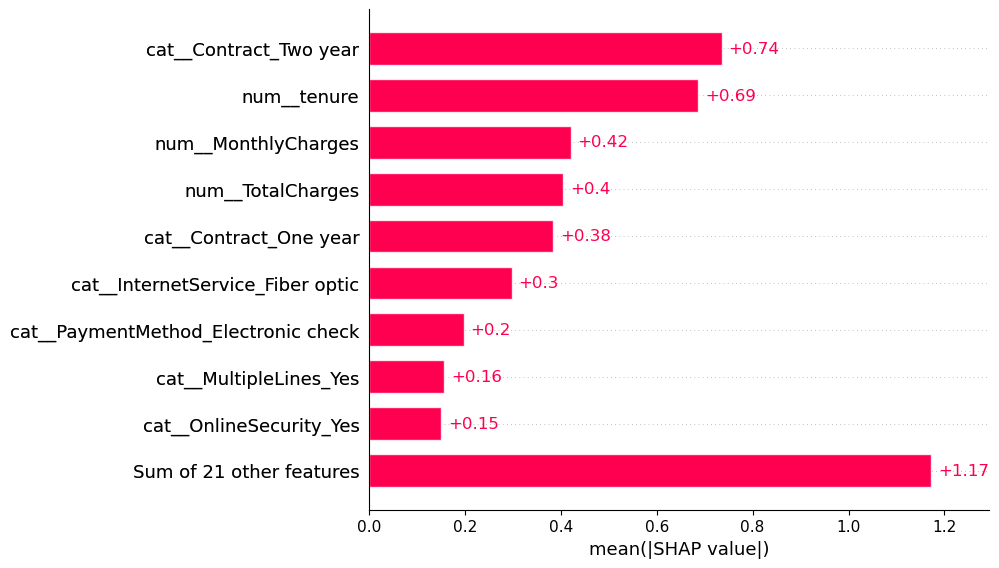

In [34]:
shap.plots.bar(shap_values)

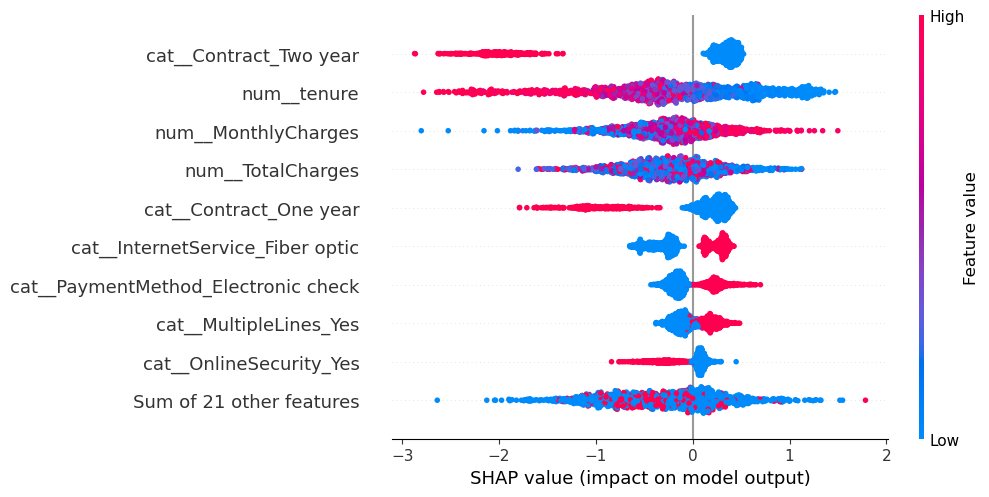

In [35]:
shap.plots.beeswarm(shap_values)

##  Conclusion

We built a churn prediction model using XGBoost, with preprocessing 
handled via a Scikit-learn Pipeline and ColumnTransformer.

**Model Performance:**
| Metric | Value |
|--------|-------|
| Accuracy | 74% |
| Churn Recall | 75% |
| Churn Precision | 51% |
| ROC AUC | 0.82 |

**Key Findings:**
- Customers on **Month-to-month contracts** are at the highest churn risk
- **Short tenure** and **high MonthlyCharges** strongly increase churn probability
- **Fiber Optic** users show a higher tendency to churn
- **Two-year contracts** are the strongest protective factor against churn

**Pipeline Highlights:**
- `ColumnTransformer` handled encoding and passthrough in a single step
- `scale_pos_weight` addressed class imbalance (73% vs 27%)
- SHAP Beeswarm confirmed that model decisions align with EDA insights

**Overall**, the model achieves strong discriminative ability (AUC = 0.82), 
making it suitable for proactive retention strategies targeting high-risk customers.

In [40]:
import pickle
with open("D:/churn_prediction_app/churn_app/model.pkl", "wb") as f:
    pickle.dump(clf, f)
